<a href="https://colab.research.google.com/github/Likhithluck/Capstone-Project/blob/likhith/Copy_of_Working_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt update
!sudo apt install -y tesseract-ocr

!pip install datasets pytesseract

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,783 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,243 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-securit

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load the dataset
ds = load_dataset("mychen76/invoices-and-receipts_ocr_v1")

# Check dataset structure
print(ds)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/782 [00:00<?, ?B/s]

(…)-00000-of-00001-76ffc8319f74dd65.parquet:   0%|          | 0.00/249M [00:00<?, ?B/s]

(…)-00000-of-00001-af2d92d1cee28514.parquet:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

(…)-00000-of-00001-894b4e1f736b5732.parquet:   0%|          | 0.00/14.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/70 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 2043
    })
    test: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 125
    })
    valid: Dataset({
        features: ['image', 'id', 'parsed_data', 'raw_data'],
        num_rows: 70
    })
})


In [ ]:
print(ds["train"][0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2481x3508 at 0x7B0AFD11A610>, 'id': '0', 'parsed_data': '{"xml": "", "json": "{\'header\': {\'invoice_no\': \'40378170\', \'invoice_date\': \'10/15/2012\', \'seller\': \'Patel, Thompson and Montgomery 356 Kyle Vista New James, MA 46228\', \'client\': \'Jackson, Odonnell and Jackson 267 John Track Suite 841 Jenniferville, PA 98601\', \'seller_tax_id\': \'958-74-3511\', \'client_tax_id\': \'998-87-7723\', \'iban\': \'GB77WRBQ31965128414006\'}, \'items\': [{\'item_desc\': \\"Leed\'s Wine Companion Bottle Corkscrew Opener Gift Box Set with Foil Cutter\\", \'item_qty\': \'1,00\', \'item_net_price\': \'7,50\', \'item_net_worth\': \'7,50\', \'item_vat\': \'10%\', \'item_gross_worth\': \'8,25\'}], \'summary\': {\'total_net_worth\': \'$7,50\', \'total_vat\': \'$0,75\', \'total_gross_worth\': \'$8,25\'}}", "kie": ""}', 'raw_data': '{"ocr_words": "[\'Invoice no: 40378170\', \'Date of issue:\', \'10/15/2012\', \'Seller:\', \'Client:\

In [ ]:
def display(image):
    dpi = 80

    # If the input is a file path, load the image
    if isinstance(image, str):
        im_data = plt.imread(image)
    elif isinstance(image, Image.Image):  # If it's a PIL Image
        im_data = np.array(image)  # Convert PIL Image to NumPy array
    else:
        raise ValueError("Input should be a file path or a PIL Image object.")

    height, width  = im_data.shape[:2]

    # What size does the figure need to be in inches to fit the image?
    figsize = width / float(dpi), height / float(dpi)

    # Create a figure of the right size with one axes that takes up the full figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    # Hide spines, ticks, etc.
    ax.axis('off')

    # Display the image.
    ax.imshow(im_data, cmap='gray')

    plt.show()

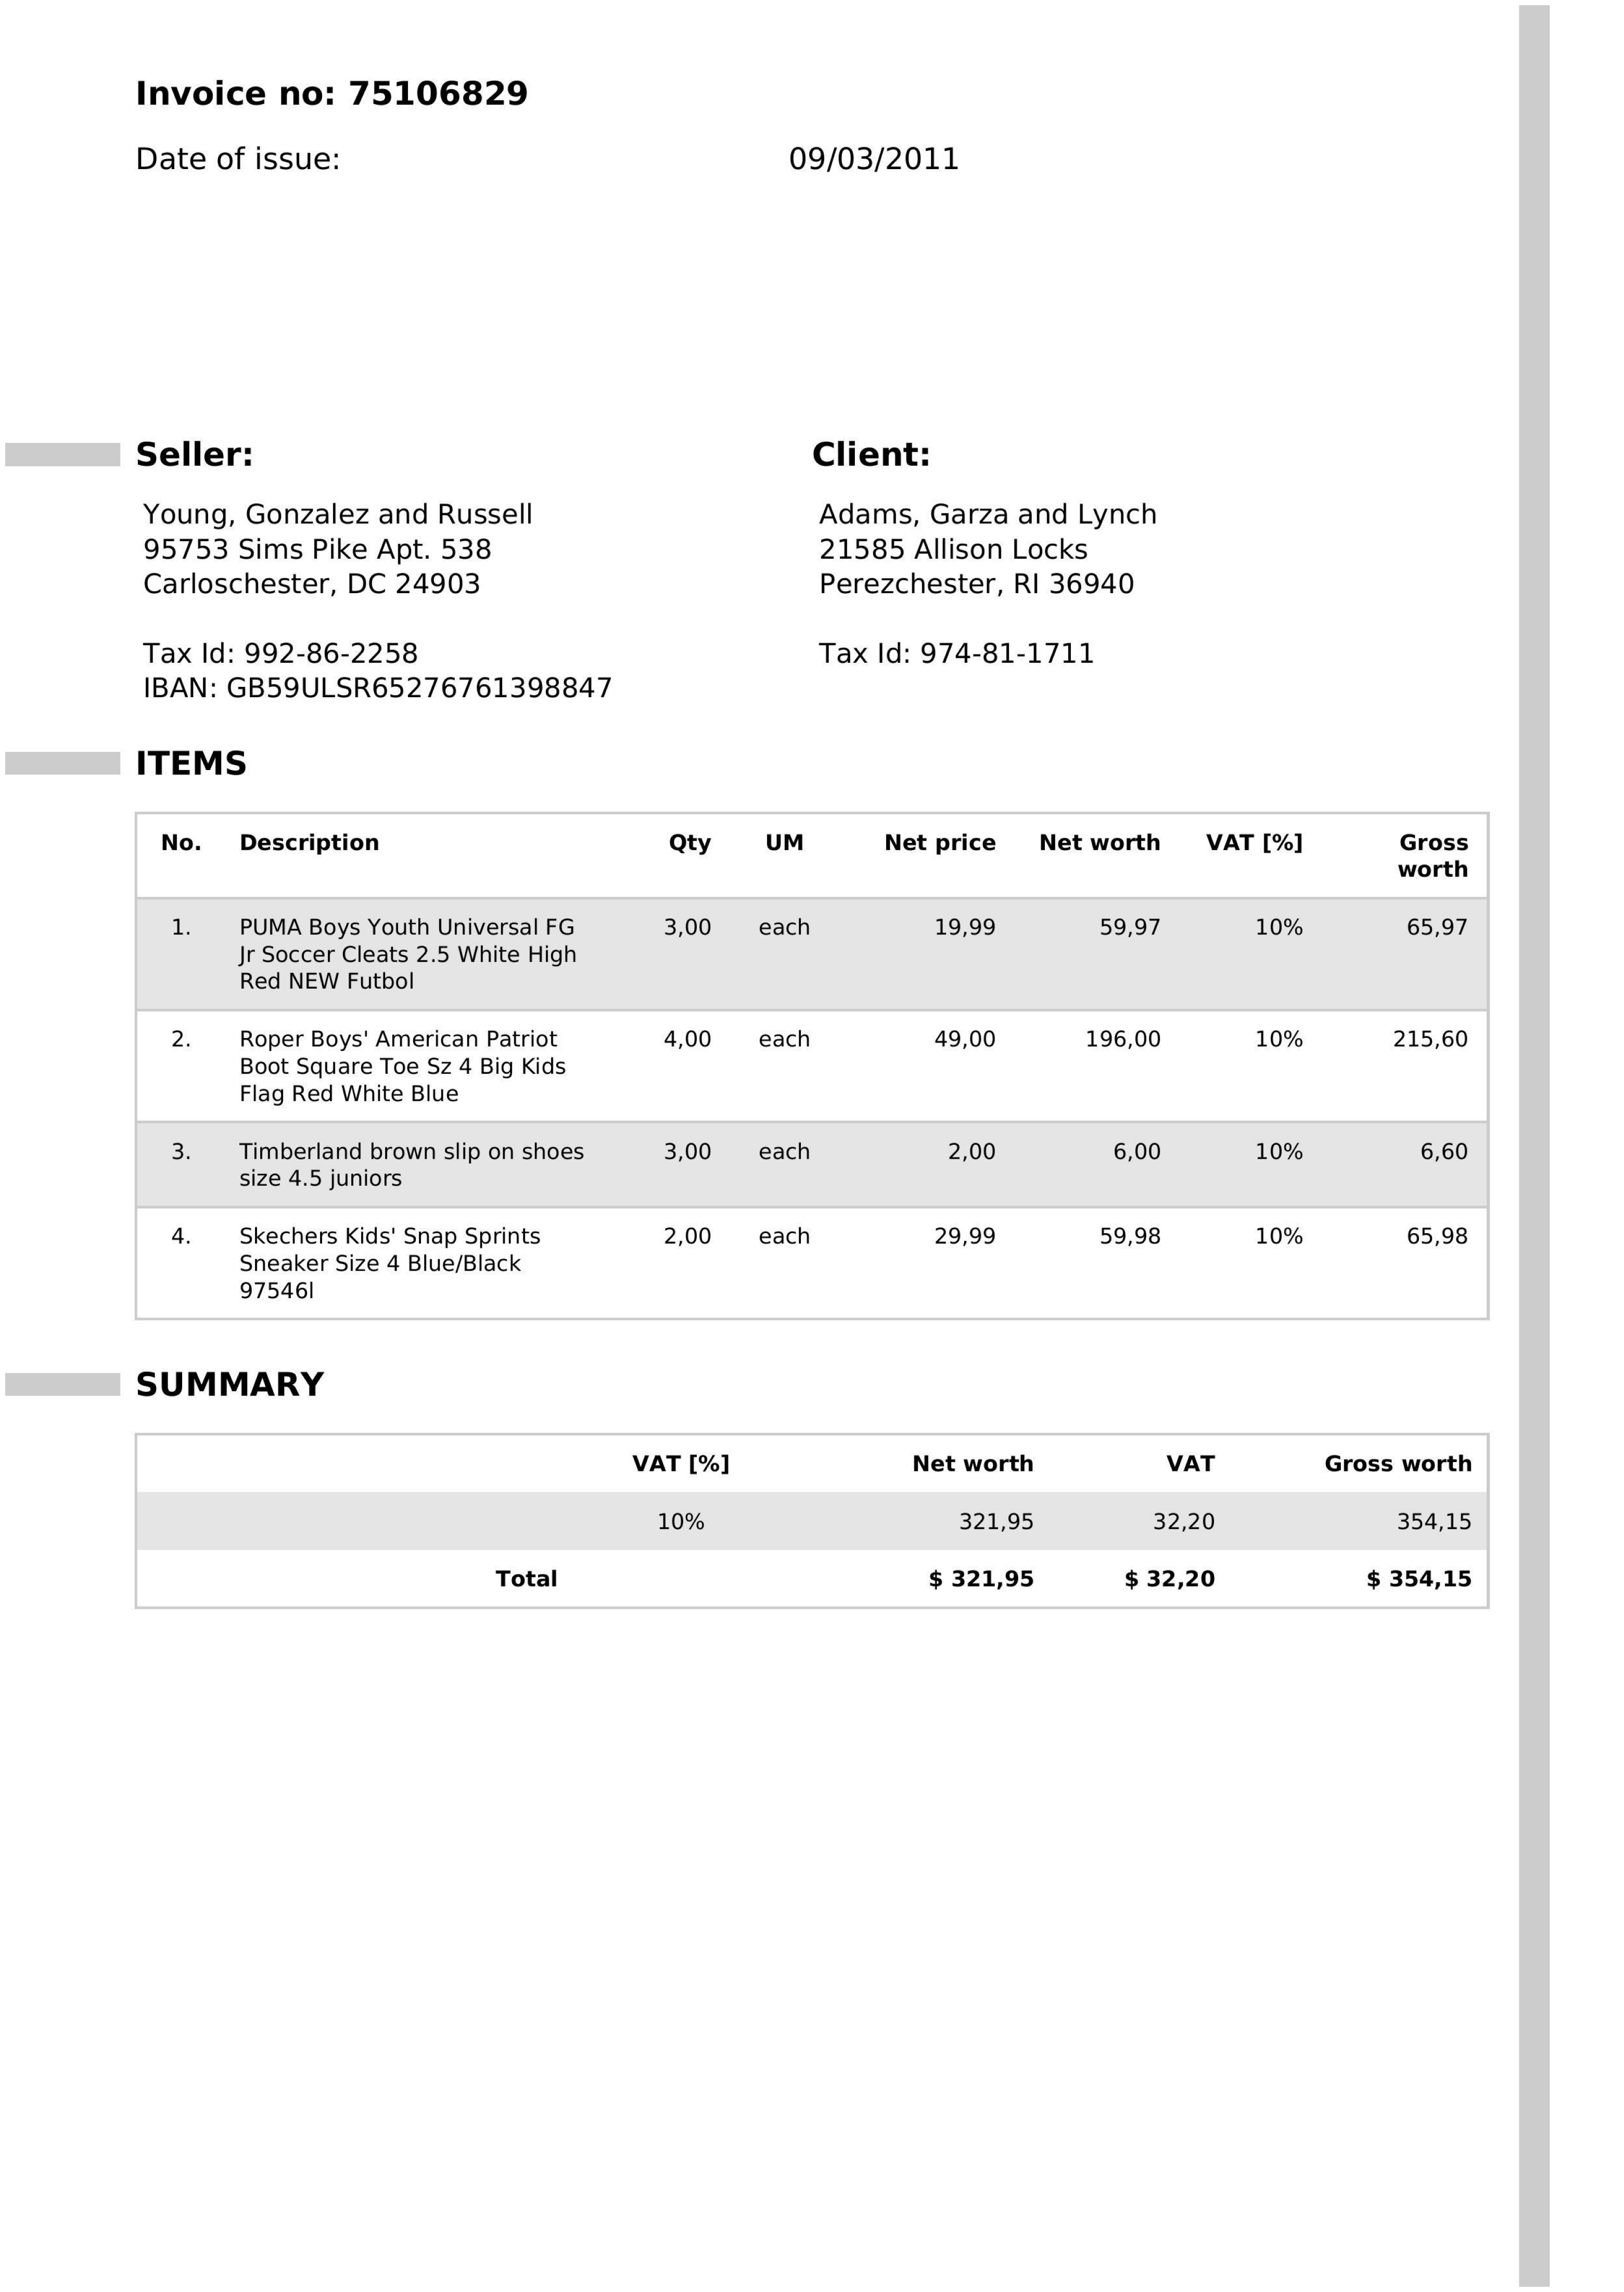

In [ ]:
# Get an image from the dataset
sample_image = ds["train"][72]["image"]  # PIL Image object

# Display the image
display(sample_image)

In [ ]:
import pytesseract

extracted_text = pytesseract.image_to_string(sample_image)

# Print the extracted text
print(extracted_text)


Invoice no: 75106829

Date of issue:

Seller:

Young, Gonzalez and Russell
95753 Sims Pike Apt. 538
Carloschester, DC 24903

Tax Id: 992-86-2258

IBAN: GB59ULSR65276761398847

ITEMS

No.

Description

PUMA Boys Youth Universal FG
Jr Soccer Cleats 2.5 White High
Red NEW Futbol

Roper Boys' American Patriot
Boot Square Toe Sz 4 Big Kids
Flag Red White Blue

Timberland brown slip on shoes
size 4.5 juniors

Skechers Kids' Snap Sprints
Sneaker Size 4 Blue/Black
97546l

SUMMARY

Total

Qty

3,00

4,00

3,00

2,00

VAT [%]

10%

09/03/2011

UM

each

each

each

each

Client:

Adams, Garza and Lynch
21585 Allison Locks
Perezchester, RI 36940

Tax Id: 974-81-1711

Net price Net worth VAT [%]
19,99 59,97 10%
49,00 196,00 10%

2,00 6,00 10%
29,99 59,98 10%
Net worth VAT
321,95 32,20
$ 321,95 $ 32,20

Gross
worth

65,97

215,60

6,60

65,98

Gross worth
354,15

$ 354,15



In [ ]:
#function to extract Invoice no

import re

# Function to extract the invoice number
def extract_invoice_number(text):
    # Search for a line that starts with "Invoice no:"
    match = re.search(r"Invoice no:\s*(\d+)", text)
    if match:
        return match.group(1)
    return None

In [ ]:
invoice_number = extract_invoice_number(extracted_text)
print("Invoice Number:", invoice_number)

Invoice Number: 75106829


In [ ]:
#function for extracting date

import re
from datetime import datetime

def extract_date(ocr_text):
    # Define possible date patterns
    date_patterns = [
        # Matches MM/DD/YYYY or DD/MM/YYYY
        r'\b(\d{1,2}/\d{1,2}/\d{4})\b',
        # Matches YYYY-MM-DD
        r'\b(\d{4}-\d{1,2}-\d{1,2})\b'
    ]

    # Try matching different patterns
    for pattern in date_patterns:
        match = re.search(pattern, ocr_text)
        if match:
            raw_date = match.group(1)

            # Convert date to standard format (YYYY-MM-DD)
            for fmt in ("%m/%d/%Y", "%d/%m/%Y", "%Y-%m-%d"):
                try:
                    formatted_date = datetime.strptime(raw_date, fmt).strftime("%Y-%m-%d")
                    return formatted_date
                except ValueError:
                    continue

    return None

In [ ]:
extracted_date = extract_date(extracted_text)
print("Date of issue:", extracted_date)

Date of issue: 2011-09-03


In [ ]:
#function for extracting seller and client details
import json
def extract_details(text):
    lines = text.split("\n")

    seller_name, seller_address, seller_tax, seller_iban = "", "", "", ""
    client_name, client_address, client_tax = "", "", ""

    seller_section, client_section = False, False
    seller_lines, client_lines = [], []

    for line in lines:
        line = line.strip()

        if line.startswith("Seller:"):
            seller_section = True
            client_section = False
            continue
        elif line.startswith("Client:"):
            seller_section = False
            client_section = True
            continue

        if seller_section:
            seller_lines.append(line)
        elif client_section:
            client_lines.append(line)

    # Extract Seller Details
    if seller_lines:
        # Skip the first empty line after "Seller:"
        seller_name = seller_lines[0] if seller_lines[1] == "" else seller_lines[1]
        seller_address = " ".join(seller_lines[2:4])
        for line in seller_lines:
            if "Tax Id:" in line:
                seller_tax = line.split(":")[1].strip()
            if "IBAN:" in line:
                seller_iban = line.split(":")[1].strip()

    # Extract Client Details
    if client_lines:
        # Skip the first empty line after "Client:"
        client_name = client_lines[0] if client_lines[1] == "" else client_lines[1]
        client_address = " ".join(client_lines[2:4])
        for line in client_lines:
            if "Tax Id:" in line:
                client_tax = line.split(":")[1].strip()

    extracted_details = {
        "Seller": {
            "Name": seller_name,
            "Address": seller_address,
            "Tax ID": seller_tax,
            "IBAN": seller_iban
        },
        "Client": {
            "Name": client_name,
            "Address": client_address,
            "Tax ID": client_tax
        }
    }

    return extracted_details

In [ ]:
structured_data = extract_details(extracted_text)
print(json.dumps(structured_data, indent=4))

{
    "Seller": {
        "Name": "Young, Gonzalez and Russell",
        "Address": "95753 Sims Pike Apt. 538 Carloschester, DC 24903",
        "Tax ID": "992-86-2258",
        "IBAN": "GB59ULSR65276761398847"
    },
    "Client": {
        "Name": "Adams, Garza and Lynch",
        "Address": "21585 Allison Locks Perezchester, RI 36940",
        "Tax ID": "974-81-1711"
    }
}


In [ ]:
import re
from datetime import datetime
import json

class InvoiceParser:

    def __init__(self, text):
        self.text = text

    # Function to extract Invoice number
    def extract_invoice_number(self):
        match = re.search(r"Invoice no:\s*(\d+)", self.text)
        if match:
            return match.group(1)
        return None

    # Function to extract Date of issue
    def extract_date(self):
        # Define possible date patterns
        date_patterns = [
            # Matches MM/DD/YYYY or DD/MM/YYYY
            r'\b(\d{1,2}/\d{1,2}/\d{4})\b',
            # Matches YYYY-MM-DD
            r'\b(\d{4}-\d{1,2}-\d{1,2})\b'
        ]

        # Try matching different patterns
        for pattern in date_patterns:
            match = re.search(pattern, self.text)
            if match:
                raw_date = match.group(1)

                # Convert date to standard format (YYYY-MM-DD)
                for fmt in ("%m/%d/%Y", "%d/%m/%Y", "%Y-%m-%d"):
                    try:
                        formatted_date = datetime.strptime(raw_date, fmt).strftime("%Y-%m-%d")
                        return formatted_date
                    except ValueError:
                        continue

        return None

    # Function to extract Seller and Client details
    def extract_details(self):
        lines = self.text.split("\n")

        seller_name, seller_address, seller_tax, seller_iban = "", "", "", ""
        client_name, client_address, client_tax = "", "", ""

        seller_section, client_section = False, False
        seller_lines, client_lines = [], []

        for line in lines:
            line = line.strip()

            if line.startswith("Seller:"):
                seller_section = True
                client_section = False
                continue
            elif line.startswith("Client:"):
                seller_section = False
                client_section = True
                continue

            if seller_section:
                seller_lines.append(line)
            elif client_section:
                client_lines.append(line)

        # Extract Seller Details
        if seller_lines:
            # Skip the first empty line after "Seller:"
            seller_name = seller_lines[0] if seller_lines[1] == "" else seller_lines[1]
            seller_address = " ".join(seller_lines[2:4])
            for line in seller_lines:
                if "Tax Id:" in line:
                    seller_tax = line.split(":")[1].strip()
                if "IBAN:" in line:
                    seller_iban = line.split(":")[1].strip()

        # Extract Client Details
        if client_lines:
            # Skip the first empty line after "Client:"
            client_name = client_lines[0] if client_lines[1] == "" else client_lines[1]
            client_address = " ".join(client_lines[2:4])
            for line in client_lines:
                if "Tax Id:" in line:
                    client_tax = line.split(":")[1].strip()

        extracted_details = {
            "Seller": {
                "Name": seller_name,
                "Address": seller_address,
                "Tax ID": seller_tax,
                "IBAN": seller_iban
            },
            "Client": {
                "Name": client_name,
                "Address": client_address,
                "Tax ID": client_tax
            }
        }

        return extracted_details

    def extract_all_info(self):
        return {
            "Invoice Number": self.extract_invoice_number(),
            "Date of Issue": self.extract_date(),
            "Seller and Client Details": self.extract_details()
        }


# Create an InvoiceParser instance
invoice_parser = InvoiceParser(extracted_text)

# Extract all details and print the structured data as JSON
structured_data = invoice_parser.extract_all_info()
print(json.dumps(structured_data, indent=4))

{
    "Invoice Number": "75106829",
    "Date of Issue": "2011-09-03",
    "Seller and Client Details": {
        "Seller": {
            "Name": "Young, Gonzalez and Russell",
            "Address": "95753 Sims Pike Apt. 538 Carloschester, DC 24903",
            "Tax ID": "992-86-2258",
            "IBAN": "GB59ULSR65276761398847"
        },
        "Client": {
            "Name": "Adams, Garza and Lynch",
            "Address": "21585 Allison Locks Perezchester, RI 36940",
            "Tax ID": "974-81-1711"
        }
    }
}


In [ ]:
#Extraction of summary details

import re

# OCR text input
text = extracted_text

# Only keep the part after the "Total" keyword — this marks the start of summary
summary_text = text.split("Total")[-1]

# Extract VAT [%]
vat_percent_match = re.search(r'VAT\s*\[\s*%\s*\]\s*(\d+%)', text)
vat_percent = vat_percent_match.group(1) if vat_percent_match else None

# Extract all money values prefixed with "$" from summary
money_matches = re.findall(r'\$ ?\d{1,3}(?:[.,]\d{2})', summary_text)

# Get the max values — assuming final values are the highest (as per your rule)
money_matches_cleaned = [match.replace(' ', '') for match in money_matches]
money_values_sorted = sorted(money_matches_cleaned, key=lambda x: float(x.replace('$', '').replace(',', '.')), reverse=True)

# Assign values based on descending order (Gross > Net > VAT)
gross_worth = money_values_sorted[0] if len(money_values_sorted) > 0 else None
net_worth = money_values_sorted[1] if len(money_values_sorted) > 1 else None
vat_value   = money_values_sorted[2] if len(money_values_sorted) > 2 else None

# Final extracted summary
summary = {
    "VAT [%]": vat_percent,
    "Net worth": net_worth,
    "VAT": vat_value,
    "Gross worth": gross_worth
}

print(summary)


{'VAT [%]': '10%', 'Net worth': '$321,95', 'VAT': '$32,20', 'Gross worth': '$354,15'}


In [ ]:
import re
from datetime import datetime
import json

class InvoiceParser:

    def __init__(self, text):
        self.text = text

    # Extract Invoice number
    def extract_invoice_number(self):
        match = re.search(r"Invoice no:\s*(\d+)", self.text)
        return match.group(1) if match else None

    # Extract Date of issue
    def extract_date(self):
        date_patterns = [
            r'\b(\d{1,2}/\d{1,2}/\d{4})\b',
            r'\b(\d{4}-\d{1,2}-\d{1,2})\b'
        ]
        for pattern in date_patterns:
            match = re.search(pattern, self.text)
            if match:
                raw_date = match.group(1)
                for fmt in ("%m/%d/%Y", "%d/%m/%Y", "%Y-%m-%d"):
                    try:
                        return datetime.strptime(raw_date, fmt).strftime("%Y-%m-%d")
                    except ValueError:
                        continue
        return None

    # Extract Seller and Client details
    def extract_details(self):
        lines = self.text.split("\n")

        seller_name, seller_address, seller_tax, seller_iban = "", "", "", ""
        client_name, client_address, client_tax = "", "", ""

        seller_section, client_section = False, False
        seller_lines, client_lines = [], []

        for line in lines:
            line = line.strip()
            if line.startswith("Seller:"):
                seller_section, client_section = True, False
                continue
            elif line.startswith("Client:"):
                seller_section, client_section = False, True
                continue
            if seller_section:
                seller_lines.append(line)
            elif client_section:
                client_lines.append(line)

        # Seller Details
        if seller_lines:
            seller_name = seller_lines[0] if seller_lines[1] == "" else seller_lines[1]
            seller_address = " ".join(seller_lines[2:4])
            for line in seller_lines:
                if "Tax Id:" in line:
                    seller_tax = line.split(":")[1].strip()
                if "IBAN:" in line:
                    seller_iban = line.split(":")[1].strip()

        # Client Details
        if client_lines:
            client_name = client_lines[0] if client_lines[1] == "" else client_lines[1]
            client_address = " ".join(client_lines[2:4])
            for line in client_lines:
                if "Tax Id:" in line:
                    client_tax = line.split(":")[1].strip()

        return {
            "Seller": {
                "Name": seller_name,
                "Address": seller_address,
                "Tax ID": seller_tax,
                "IBAN": seller_iban
            },
            "Client": {
                "Name": client_name,
                "Address": client_address,
                "Tax ID": client_tax
            }
        }

    # Extract summary values
    def extract_summary_values(self):
        # Only use text after "Total" for summary section
        summary_text = self.text.split("Total")[-1]
        summary_text_clean = summary_text.replace('\n', ' ').lower()

        # VAT [%]
        vat_percent_match = re.search(r'vat\s*\[?\s*%\s*\]?\s*(\d+%)', self.text, re.IGNORECASE)
        vat_percent = vat_percent_match.group(1) if vat_percent_match else None

        # Extract money values (like $126,96)
        money_matches = re.findall(r'\$ ?\d{1,3}(?:[.,]\d{2})', summary_text_clean)
        money_cleaned = [m.replace(' ', '') for m in money_matches]
        money_sorted = sorted(
            money_cleaned,
            key=lambda x: float(x.replace('$', '').replace(',', '.')),
            reverse=True
        )

        gross_worth = money_sorted[0] if len(money_sorted) > 0 else None
        net_worth = money_sorted[1] if len(money_sorted) > 1 else None
        vat_value  = money_sorted[2] if len(money_sorted) > 2 else None

        return {
            "VAT [%]": vat_percent,
            "Net worth": net_worth,
            "VAT": vat_value,
            "Gross worth": gross_worth
        }

    # Combine everything into one call
    def extract_all_info(self):
        return {
            "Invoice Number": self.extract_invoice_number(),
            "Date of Issue": self.extract_date(),
            "Seller and Client Details": self.extract_details(),
            "Summary": self.extract_summary_values()
        }

# EXAMPLE
ocr_text = extracted_text

invoice_parser = InvoiceParser(extracted_text)
structured_data = invoice_parser.extract_all_info()

# Pretty print
print(json.dumps(structured_data, indent=4))


{
    "Invoice Number": "75106829",
    "Date of Issue": "2011-09-03",
    "Seller and Client Details": {
        "Seller": {
            "Name": "Young, Gonzalez and Russell",
            "Address": "95753 Sims Pike Apt. 538 Carloschester, DC 24903",
            "Tax ID": "992-86-2258",
            "IBAN": "GB59ULSR65276761398847"
        },
        "Client": {
            "Name": "Adams, Garza and Lynch",
            "Address": "21585 Allison Locks Perezchester, RI 36940",
            "Tax ID": "974-81-1711"
        }
    },
    "Summary": {
        "VAT [%]": "10%",
        "Net worth": "$321,95",
        "VAT": "$32,20",
        "Gross worth": "$354,15"
    }
}


In [7]:
from nbformat import read, write, NO_CONVERT

with open("Copy_of_Working_code.ipynb") as f:
    nb = read(f, as_version=NO_CONVERT)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

with open("your_notebook_clean.ipynb", "w") as f:
    write(nb, f)

['.config', 'Copy_of_Working_code.ipynb', 'sample_data']
